### Sampling 10%

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# ============================================================================
# 1. LOAD DATA PREPROCESSED
# ============================================================================

df = pd.read_csv('dataset_preprocessed.csv')
print(f"Total data: {len(df)}")
print(f"Kolom: {df.columns.tolist()}")

Total data: 9577
Kolom: ['text_preprocessed']


In [3]:
# ============================================================================
# 2. AMBIL SAMPEL 10% SECARA RANDOM
# ============================================================================

# Set random seed untuk reproducibility
np.random.seed(42)

# Ambil 10% data secara random
sample_size = int(len(df) * 0.1)
df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"\n{'='*80}")
print(f"SAMPEL DATA (10%)")
print(f"{'='*80}")
print(f"Total sampel: {len(df_sample)}")
print(f"Persentase: {(len(df_sample)/len(df))*100:.2f}%")

# Simpan sampel untuk referensi
df_sample.to_csv('dataset_sampling.csv', index=False)
print(f"✅ Sampel disimpan ke: dataset_sampling.csv")


SAMPEL DATA (10%)
Total sampel: 957
Persentase: 9.99%
✅ Sampel disimpan ke: dataset_sampling.csv


In [4]:
# ============================================================================
# 3. METODE 1: LEXICON-BASED LABELING (3 CLASS)
# ============================================================================

print(f"\n{'='*80}")
print(f"METODE 1: LEXICON-BASED LABELING")
print(f"{'='*80}")

import requests

# Load lexicon
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

print(f"Positive words: {len(positive_lexicon)}")
print(f"Negative words: {len(negative_lexicon)}")

# Fungsi labeling lexicon
def lexicon_sentiment(text):
    if isinstance(text, str):
        words = text.split()
        positive_count = sum(1 for word in words if word in positive_lexicon)
        negative_count = sum(1 for word in words if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        
        if sentiment_score > 0:
            return "positive", sentiment_score
        elif sentiment_score < 0:
            return "negative", sentiment_score
        else:
            return "neutral", sentiment_score
    return "neutral", 0

# Proses labeling dengan lexicon
results_lexicon = df_sample['text_preprocessed'].apply(
    lambda x: pd.Series(lexicon_sentiment(x), index=['sentiment_lexicon', 'score_lexicon'])
)

df_sample = pd.concat([df_sample, results_lexicon], axis=1)

print("\nDistribusi Sentimen (Lexicon):")
print(df_sample['sentiment_lexicon'].value_counts())
print("\nPersentase:")
print(df_sample['sentiment_lexicon'].value_counts(normalize=True) * 100)



METODE 1: LEXICON-BASED LABELING
Positive words: 3610
Negative words: 6608

Distribusi Sentimen (Lexicon):
sentiment_lexicon
negative    588
neutral     265
positive    104
Name: count, dtype: int64

Persentase:
sentiment_lexicon
negative    61.442006
neutral     27.690700
positive    10.867294
Name: proportion, dtype: float64


In [5]:
# ============================================================================
# 4. METODE 2: INDOBERT AUTO-LABELING
# ============================================================================

print(f"\n{'='*80}")
print(f"METODE 2: INDOBERT AUTO-LABELING")
print(f"{'='*80}")

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from tqdm import tqdm

# Load model
pretrained = "mdhugol/indonesia-bert-sentiment-classification"
model = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer = AutoTokenizer.from_pretrained(pretrained)
sentiment_analysis = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# Mapping label
label_index = {'LABEL_0': 'positive', 'LABEL_1': 'neutral', 'LABEL_2': 'negative'}

# Fungsi labeling dengan error handling
def indobert_sentiment(text):
    try:
        if pd.isna(text) or text.strip() == "":
            return 'neutral', 0.0
        
        text = str(text)[:512]
        result = sentiment_analysis(text)
        label = label_index[result[0]['label']]
        score = result[0]['score']
        
        return label, score
    except Exception as e:
        print(f"Error: {text[:50]}... | {e}")
        return 'neutral', 0.0

# Proses labeling dengan IndoBERT
print("\nMemproses dengan IndoBERT...")
labels_bert = []
scores_bert = []

for i, text in enumerate(tqdm(df_sample['text_preprocessed'], desc="Processing")):
    label, score = indobert_sentiment(text)
    labels_bert.append(label)
    scores_bert.append(score)
    
    if i % 50 == 0:
        print(f"Sample {i+1}: {text[:40]}... | {label} ({score:.3f})")

df_sample['sentiment_indobert'] = labels_bert
df_sample['confidence_indobert'] = scores_bert

print("\nDistribusi Sentimen (IndoBERT):")
print(df_sample['sentiment_indobert'].value_counts())
print("\nPersentase:")
print(df_sample['sentiment_indobert'].value_counts(normalize=True) * 100)
print(f"\nRata-rata confidence score: {df_sample['confidence_indobert'].mean():.3f}")



METODE 2: INDOBERT AUTO-LABELING


d:\Data\Kuliah\Semester 7\Skripsi\tiktok-indobert\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use cpu



Memproses dengan IndoBERT...


Processing:   0%|          | 1/957 [00:00<02:00,  7.94it/s]

Sample 1: klu nga didemo mungkin tiap bulanlalu di... | negative (0.976)


...

Sample 901: tetapi banyak loh daerah saya rumah dewa... | negative (0.921)


Processing: 100%|█████████▉| 954/957 [00:30<00:00, 33.62it/s]

Sample 951: betul... | positive (0.992)


Processing: 100%|██████████| 957/957 [00:30<00:00, 31.49it/s]


Distribusi Sentimen (IndoBERT):
sentiment_indobert
negative    629
neutral     170
positive    158
Name: count, dtype: int64

Persentase:
sentiment_indobert
negative    65.726228
neutral     17.763845
positive    16.509927
Name: proportion, dtype: float64

Rata-rata confidence score: 0.899



PERBANDINGAN HASIL

Agreement antara kedua metode:
Jumlah data yang sama: 531/957
Persentase agreement: 55.49%

CONFUSION MATRIX (Lexicon vs IndoBERT)


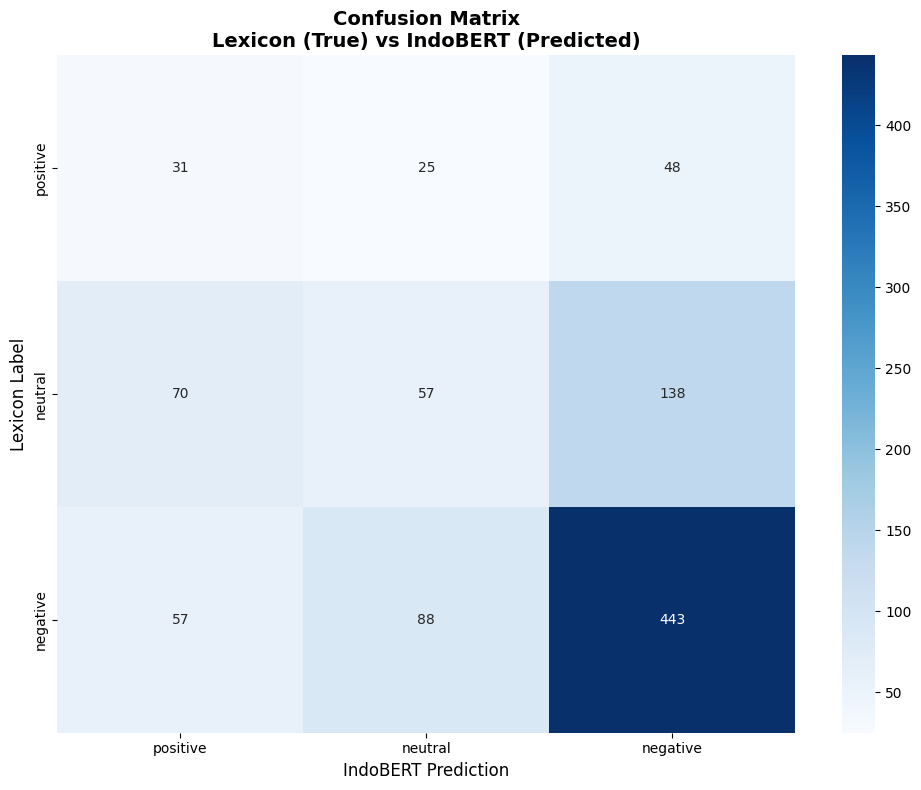


✅ Confusion matrix disimpan ke: confusion_matrix_comparison.png


In [6]:
# ============================================================================
# 5. PERBANDINGAN HASIL KEDUA METODE
# ============================================================================

print(f"\n{'='*80}")
print(f"PERBANDINGAN HASIL")
print(f"{'='*80}")

# Hitung agreement
agreement = (df_sample['sentiment_lexicon'] == df_sample['sentiment_indobert']).sum()
agreement_pct = (agreement / len(df_sample)) * 100

print(f"\nAgreement antara kedua metode:")
print(f"Jumlah data yang sama: {agreement}/{len(df_sample)}")
print(f"Persentase agreement: {agreement_pct:.2f}%")

# Confusion matrix antara kedua metode
print("\n" + "="*80)
print("CONFUSION MATRIX (Lexicon vs IndoBERT)")
print("="*80)

from sklearn.metrics import confusion_matrix
import seaborn as sns

labels_order = ['positive', 'neutral', 'negative']
cm = confusion_matrix(
    df_sample['sentiment_lexicon'], 
    df_sample['sentiment_indobert'],
    labels=labels_order
)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, 
            yticklabels=labels_order)
plt.title('Confusion Matrix\nLexicon (True) vs IndoBERT (Predicted)', fontsize=14, fontweight='bold')
plt.xlabel('IndoBERT Prediction', fontsize=12)
plt.ylabel('Lexicon Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix disimpan ke: confusion_matrix_comparison.png")


In [ ]:
# ============================================================================
# 6. ANALISIS PERBEDAAN
# ============================================================================

print(f"\n{'='*80}")
print(f"ANALISIS PERBEDAAN")
print(f"{'='*80}")

# Cari data yang berbeda
df_different = df_sample[df_sample['sentiment_lexicon'] != df_sample['sentiment_indobert']].copy()

print(f"\nJumlah data yang berbeda: {len(df_different)}")
print(f"Persentase: {(len(df_different)/len(df_sample))*100:.2f}%")

if len(df_different) > 0:
    print("\n10 Contoh data yang berbeda:")
    print("="*100)
    
    for idx, row in df_different.head(10).iterrows():
        print(f"\nText: {row['text_preprocessed'][:80]}...")
        print(f"  Lexicon    : {row['sentiment_lexicon']} (score: {row['score_lexicon']})")
        print(f"  IndoBERT   : {row['sentiment_indobert']} (confidence: {row['confidence_indobert']:.3f})")
        print("-"*100)


ANALISIS PERBEDAAN

Jumlah data yang berbeda: 426
Persentase: 44.51%

10 Contoh data yang berbeda:

Text: uang apresiasi berapa pak kd saja jt...
  Lexicon    : negative (score: -1)
  IndoBERT   : neutral (confidence: 0.912)
----------------------------------------------------------------------------------------------------

Text: mangkanya terbuka lol...
  Lexicon    : neutral (score: 0)
  IndoBERT   : positive (confidence: 0.505)
----------------------------------------------------------------------------------------------------

Text: oktokt bulan artinya jt...
  Lexicon    : negative (score: -1)
  IndoBERT   : neutral (confidence: 0.955)
----------------------------------------------------------------------------------------------------

Text: benar lah itu mewakilkan mewakilkan makan enak mewakilkan tidur enak mewakilkan ...
  Lexicon    : negative (score: -1)
  IndoBERT   : positive (confidence: 0.694)
-----------------------------------------------------------------------------


VISUALISASI DISTRIBUSI


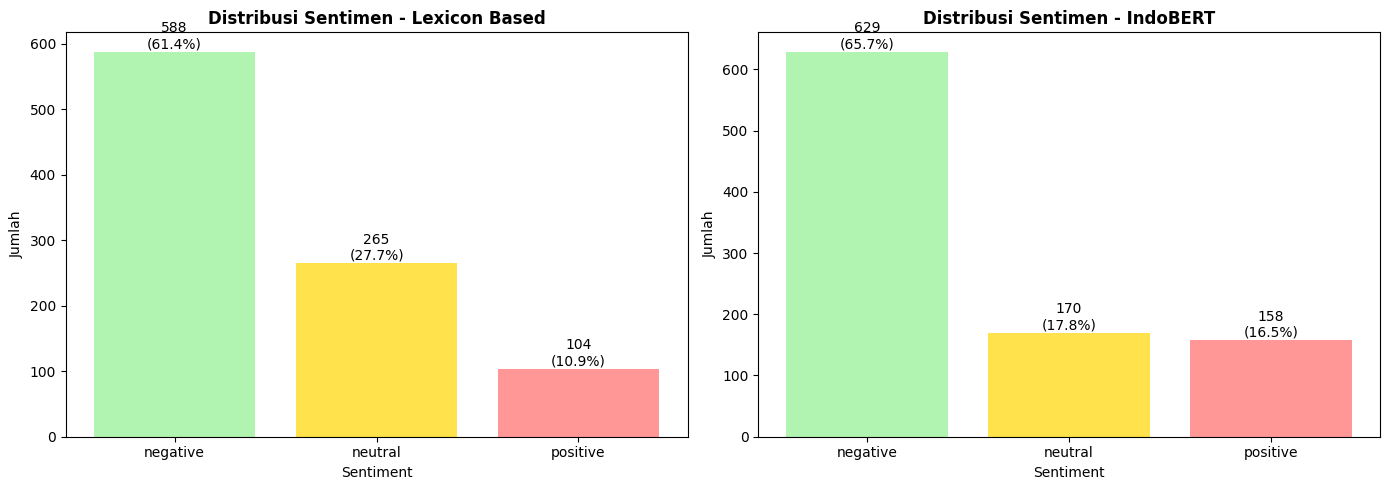


✅ Grafik distribusi disimpan ke: sentiment_distribution_comparison.png


In [8]:
# ============================================================================
# 7. DISTRIBUSI PERBANDINGAN
# ============================================================================

print(f"\n{'='*80}")
print(f"VISUALISASI DISTRIBUSI")
print(f"{'='*80}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Lexicon
sentiment_count_lex = df_sample['sentiment_lexicon'].value_counts()
colors_lex = ['#90EE90', '#FFD700', '#FF6B6B']
axes[0].bar(sentiment_count_lex.index, sentiment_count_lex.values, color=colors_lex, alpha=0.7)
axes[0].set_title('Distribusi Sentimen - Lexicon Based', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Jumlah')

for i, (label, count) in enumerate(sentiment_count_lex.items()):
    pct = (count / len(df_sample)) * 100
    axes[0].text(i, count + 5, f'{count}\n({pct:.1f}%)', ha='center', fontsize=10)

# Plot 2: IndoBERT
sentiment_count_bert = df_sample['sentiment_indobert'].value_counts()
colors_bert = ['#90EE90', '#FFD700', '#FF6B6B']
axes[1].bar(sentiment_count_bert.index, sentiment_count_bert.values, color=colors_bert, alpha=0.7)
axes[1].set_title('Distribusi Sentimen - IndoBERT', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Jumlah')

for i, (label, count) in enumerate(sentiment_count_bert.items()):
    pct = (count / len(df_sample)) * 100
    axes[1].text(i, count + 5, f'{count}\n({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('sentiment_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Grafik distribusi disimpan ke: sentiment_distribution_comparison.png")


In [10]:
# ============================================================================
# 8. SIMPAN HASIL
# ============================================================================

print(f"\n{'='*80}")
print(f"MENYIMPAN HASIL")
print(f"{'='*80}")

# Simpan hasil lengkap
output_file = 'dataset_sample_labeled_comparison.csv'
df_sample.to_csv(output_file, index=False)
print(f"✅ Hasil perbandingan disimpan ke: {output_file}")

# Simpan hanya data yang berbeda
if len(df_different) > 0:
    output_diff = 'dataset_sample_different_labels.csv'
    df_different.to_csv(output_diff, index=False)
    print(f"✅ Data dengan label berbeda disimpan ke: {output_diff}")



MENYIMPAN HASIL
✅ Hasil perbandingan disimpan ke: dataset_sample_labeled_comparison.csv
✅ Data dengan label berbeda disimpan ke: dataset_sample_different_labels.csv


In [11]:
# ============================================================================
# 9. SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print(f"📊 SUMMARY PERBANDINGAN")
print(f"{'='*80}")

summary = f"""
📌 DATA SUMMARY:
   • Total data asli        : {len(df):,}
   • Data sampel (10%)      : {len(df_sample):,}
   
📌 LEXICON-BASED LABELING:
   • Positive  : {df_sample['sentiment_lexicon'].value_counts().get('positive', 0)} ({(df_sample['sentiment_lexicon'].value_counts().get('positive', 0)/len(df_sample)*100):.1f}%)
   • Neutral   : {df_sample['sentiment_lexicon'].value_counts().get('neutral', 0)} ({(df_sample['sentiment_lexicon'].value_counts().get('neutral', 0)/len(df_sample)*100):.1f}%)
   • Negative  : {df_sample['sentiment_lexicon'].value_counts().get('negative', 0)} ({(df_sample['sentiment_lexicon'].value_counts().get('negative', 0)/len(df_sample)*100):.1f}%)

📌 INDOBERT AUTO-LABELING:
   • Positive  : {df_sample['sentiment_indobert'].value_counts().get('positive', 0)} ({(df_sample['sentiment_indobert'].value_counts().get('positive', 0)/len(df_sample)*100):.1f}%)
   • Neutral   : {df_sample['sentiment_indobert'].value_counts().get('neutral', 0)} ({(df_sample['sentiment_indobert'].value_counts().get('neutral', 0)/len(df_sample)*100):.1f}%)
   • Negative  : {df_sample['sentiment_indobert'].value_counts().get('negative', 0)} ({(df_sample['sentiment_indobert'].value_counts().get('negative', 0)/len(df_sample)*100):.1f}%)
   • Avg Confidence: {df_sample['confidence_indobert'].mean():.3f}

📌 PERBANDINGAN:
   • Agreement             : {agreement}/{len(df_sample)} ({agreement_pct:.2f}%)
   • Disagreement          : {len(df_different)}/{len(df_sample)} ({(len(df_different)/len(df_sample)*100):.2f}%)

📌 OUTPUT FILES:
   ✅ {output_file}
   ✅ confusion_matrix_comparison.png
   ✅ sentiment_distribution_comparison.png
   {'✅ ' + output_diff if len(df_different) > 0 else ''}

📌 NEXT STEPS:
   1. Review data dengan label berbeda
   2. Lakukan manual labeling pada sampel untuk validasi
   3. Pilih metode terbaik atau kombinasi keduanya
   4. Terapkan ke seluruh dataset
"""

print(summary)
print("="*80)


📊 SUMMARY PERBANDINGAN

📌 DATA SUMMARY:
   • Total data asli        : 9,577
   • Data sampel (10%)      : 957

📌 LEXICON-BASED LABELING:
   • Positive  : 104 (10.9%)
   • Neutral   : 265 (27.7%)
   • Negative  : 588 (61.4%)

📌 INDOBERT AUTO-LABELING:
   • Positive  : 158 (16.5%)
   • Neutral   : 170 (17.8%)
   • Negative  : 629 (65.7%)
   • Avg Confidence: 0.899

📌 PERBANDINGAN:
   • Agreement             : 531/957 (55.49%)
   • Disagreement          : 426/957 (44.51%)

📌 OUTPUT FILES:
   ✅ dataset_sample_labeled_comparison.csv
   ✅ confusion_matrix_comparison.png
   ✅ sentiment_distribution_comparison.png
   ✅ dataset_sample_different_labels.csv

📌 NEXT STEPS:
   1. Review data dengan label berbeda
   2. Lakukan manual labeling pada sampel untuk validasi
   3. Pilih metode terbaik atau kombinasi keduanya
   4. Terapkan ke seluruh dataset

